In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.


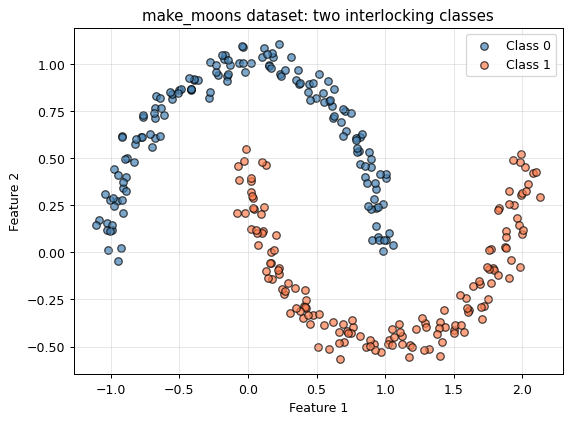

In [6]:
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Mejores hiperparámetros encontrados: {'max_depth': 6, 'min_samples_leaf': 5}
Decision Tree accuracy (test): 0.850


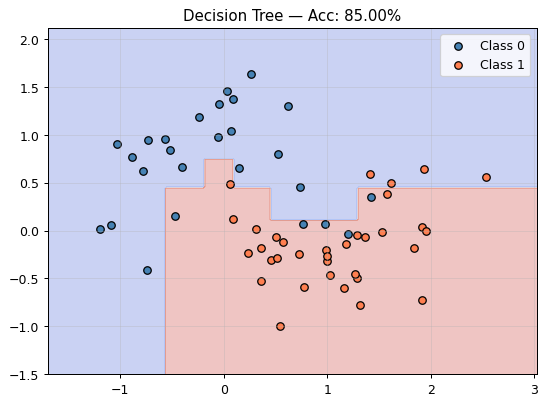

In [5]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 1. Instanciamos el Árbol de Decisión
tree = DecisionTreeClassifier(random_state=42)

# 2. Definimos una grilla de hiperparámetros para evitar el sobreajuste (overfitting)
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 5, 10, 15]
}

# 3. Usamos GridSearchCV para encontrar la mejor combinación
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 4. Extraemos el mejor modelo
best_tree = grid_search.best_estimator_

# 5. Evaluamos el accuracy con los datos de prueba
acc_tree = accuracy_score(y_test, best_tree.predict(X_test))

print(f'Mejores hiperparámetros encontrados: {grid_search.best_params_}')
print(f'Decision Tree accuracy (test): {acc_tree:.3f}')

# 6. Graficamos la nueva frontera de decisión
plot_decision_boundary(best_tree, X_test, y_test, f'Decision Tree — Acc: {acc_tree:.2%}')